In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib

In [123]:
df_original = pd.read_csv("LLAN0095_total.csv")

In [124]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

In [125]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','Pd', 'Ti','Tm', 'VX','RUN FREQ.', 'Pi']]

# eliminar temperaturas valor 0
df = df[(df['Ti'] != 0) & (df['Tm'] != 0)]

# Eliminar los nan
df= df.dropna()

In [126]:
def sqrt(x):
    return x ** 0.5

In [127]:
archivo = "Coeficientes.xlsx"

df_pump = pd.read_excel(
    archivo,
    sheet_name="Pump"
)

df_motor = pd.read_excel(
    archivo,
    sheet_name="Motor"
)

motor = df_motor[(df_motor['Type'] == 'XT1-S') & 
         (df_motor['Series'] == 560) & 
         (df_motor['Nameplate HP'] == 391.0) & 
         (df_motor['Nameplate Voltage'] == 3564) & 
         (df_motor['Nameplate Current'] == 92.6)]

pump = df_pump[(df_pump['Series'] == '400') & (df_pump['Model'] == 'WD1000ZX')]

LF = df['AVOA'] / motor ['Nameplate Current'].values[0]
FP =(motor['P0'].values[0] + 
    (motor['P1'].values[0] * LF) +  
    (motor['P2'].values[0] * LF**2) + 
    (motor['P3'].values[0] * LF**3) + 
    (motor['P4'].values[0] * LF**4) + 
    (motor['P5'].values[0] * LF**5))/100

ef_m = (motor['E0'].values[0] +
        (motor['E1'].values[0] * LF) +
        (motor['E2'].values[0] * LF**2) +
        (motor['E3'].values[0] * LF**3) +
        (motor['E4'].values[0] * LF**4) +
        (motor['E5'].values[0] * LF**5))/100

ef_p = pump['Max Efficiency'].values[0]

df = df.copy()
df['Caudal'] = (58847 * sqrt(3) * df['AVOV'] * df['AVOA'] * FP * ef_m * ef_p) / (746 * (df['Pd'] - df['Pi']))

In [128]:
# Eliminar filas donde caudal sea pequeno o grande
df = df[(df['Caudal'] >= 0) & (df['Caudal'] <= 2000)]

In [129]:
df = df.copy()
df['AMA_lag_1']  = df['AMA'].shift(1)
df['AMA_lag_2']  = df['AMA'].shift(2)
df['AMA_lag_5']  = df['AMA'].shift(5)
df['AMA_lag_15'] = df['AMA'].shift(15)
df['AMA_lag_30'] = df['AMA'].shift(30)
df['AMA_mean_30'] = df['AMA'].rolling(30).mean()
df['AMA_std_30'] = df['AMA'].rolling(30).std()

df['AVOV_lag_1']  = df['AVOV'].shift(1)
df['AVOV_lag_2']  = df['AVOV'].shift(2)
df['AVOV_lag_5']  = df['AVOV'].shift(5)
df['AVOV_lag_15'] = df['AVOV'].shift(15)
df['AVOV_lag_30'] = df['AVOV'].shift(30)
df['AVOV_mean_30'] = df['AVOV'].rolling(30).mean()
df['AVOV_std_30'] = df['AVOV'].rolling(30).std()

df['Caudal_lag_1']  = df['Caudal'].shift(1)
df['Caudal_lag_2']  = df['Caudal'].shift(2)
df['Caudal_lag_5']  = df['Caudal'].shift(5)
df['Caudal_lag_15'] = df['Caudal'].shift(15)
df['Caudal_lag_30'] = df['Caudal'].shift(30)
df['Caudal_mean_30'] = df['Caudal'].rolling(30).mean()
df['Caudal_std_30'] = df['Caudal'].rolling(30).std()

df['Ti_lag_31']  = df['Ti'].shift(31)
df['Ti_lag_32']  = df['Ti'].shift(32)
df['Ti_lag_35']  = df['Ti'].shift(35)
df['Ti_lag_45'] = df['Ti'].shift(45)
df['Ti_lag_60'] = df['Ti'].shift(60)
df['Ti_mean_31_60'] = df['Ti'].shift(30).rolling(30).mean()
df['Ti_std_31_60'] = df['Ti'].shift(30).rolling(30).std()

df['Tm_lag_31']  = df['Tm'].shift(31)
df['Tm_lag_32']  = df['Tm'].shift(32)
df['Tm_lag_35']  = df['Tm'].shift(35)
df['Tm_lag_45'] = df['Tm'].shift(45)
df['Tm_lag_60'] = df['Tm'].shift(60)
df['Tm_mean_31_60'] = df['Tm'].shift(30).rolling(30).mean()
df['Tm_std_31_60'] = df['Tm'].shift(30).rolling(30).std()

df['VX_lag_31']  = df['VX'].shift(31)
df['VX_lag_32']  = df['VX'].shift(32)
df['VX_lag_35']  = df['VX'].shift(35)
df['VX_lag_45'] = df['VX'].shift(45)
df['VX_lag_60'] = df['VX'].shift(60)
df['VX_mean_31_60'] = df['VX'].shift(30).rolling(30).mean()
df['VX_std_31_60'] = df['VX'].shift(30).rolling(30).std()

In [130]:
df = df.copy()
# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])
# ordenar cronológicamente
df = df.sort_values('Date')
# colocar fecha como índice
df = df.set_index('Date')

# Deep Learning

In [ ]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    'Caudal',
    'Tm',

    'AMA_mean_30',
    'AMA_std_30',

    'AVOV_mean_30',
    'AVOV_std_30',    
]

target = 'Ti'

df_model = df[features + [target]].copy()
df_model.dropna(inplace=True)

In [132]:
X = df_model[features].values
y = df_model[target].values

n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)


# TRAIN
X_train = X[:train_end]
y_train = y[:train_end]

# VALIDATION
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

# TEST
X_test = X[val_end:]
y_test = y[val_end:]

In [133]:
scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

### Crear secuencias

In [134]:
SEQ_LEN = 30
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print(X_train_seq.shape)
print(X_val_seq.shape)
print(X_test_seq.shape)

(647949, 30, 11)
(138823, 30, 11)
(138823, 30, 11)


### crear modelo

In [135]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B = x.size(0)
        h0 = x.new_zeros(self.lstm.num_layers, B, self.lstm.hidden_size)
        c0 = x.new_zeros(self.lstm.num_layers, B, self.lstm.hidden_size)

        out, _ = self.lstm(x, (h0, c0))
        h_last = out[:, -1, :]
        return self.head(h_last)

In [136]:
input_size = X_train_seq.shape[2]

print(input_size)

11


In [137]:
model = LSTMModel(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
)

In [138]:
print(model)

LSTMModel(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [139]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 212,609


In [140]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Convertir a tensores

In [141]:
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

In [142]:
train_dataset = TensorDataset(X_train_t,y_train_t)
val_dataset = TensorDataset(X_val_t,y_val_t)
test_dataset = TensorDataset(X_test_t,y_test_t)

In [143]:
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=False)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [144]:
model = model.to(device)

In [145]:
criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [146]:
history = {
    "train_loss": [],
    "val_loss": []
}

In [147]:
patience = 5
best_val_loss = float("inf")
counter = 0

In [148]:
# ENTRENAMIENTO

EPOCHS = 40

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)
        optimizer.zero_grad()
        y_hat = model(xb)
        loss = criterion(y_hat, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)
            y_hat = model(xb)
            loss = criterion(y_hat, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # HISTORIAL
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # PRINT
    print(f"""
Epoch {epoch+1}
Train Loss: {train_loss:.6f}
Val Loss:   {val_loss:.6f}
""")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "best_lstm_model.pth"
        )
    else:
        counter += 1
    if counter >= patience:
        print(f"⛔ Early stopping en epoch {epoch+1}")
        break


Epoch 1
Train Loss: 18.062242
Val Loss:   1.783990


Epoch 2
Train Loss: 9.726692
Val Loss:   3.014468


Epoch 3
Train Loss: 9.661445
Val Loss:   1.330916


Epoch 4
Train Loss: 9.863671
Val Loss:   5.287797


Epoch 5
Train Loss: 9.954750
Val Loss:   0.074863


Epoch 6
Train Loss: 9.900910
Val Loss:   1.624688


Epoch 7
Train Loss: 10.603852
Val Loss:   1.917913


Epoch 8
Train Loss: 11.317382
Val Loss:   2.153424


Epoch 9
Train Loss: 11.213440
Val Loss:   2.236464


Epoch 10
Train Loss: 11.071479
Val Loss:   2.141572

⛔ Early stopping en epoch 10


### Prediccion

In [149]:
# PREDICCIONES TEST

model.eval()
preds = []
reals = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        y_hat = model(xb)
        preds.append(
            y_hat.cpu().numpy()
        )
        reals.append(
            yb.numpy()
        )

In [150]:
# CONCATENAR

y_pred_lstm = np.concatenate(preds).flatten()
y_real_lstm = np.concatenate(reals).flatten()

In [151]:
# MÉTRICAS

rmse = np.sqrt(mean_squared_error(y_real_lstm,y_pred_lstm))
mae = mean_absolute_error(y_real_lstm,y_pred_lstm)
r2 = r2_score(y_real_lstm,y_pred_lstm)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

RMSE: 2.7219
MAE : 2.6404
R2  : -4.3984


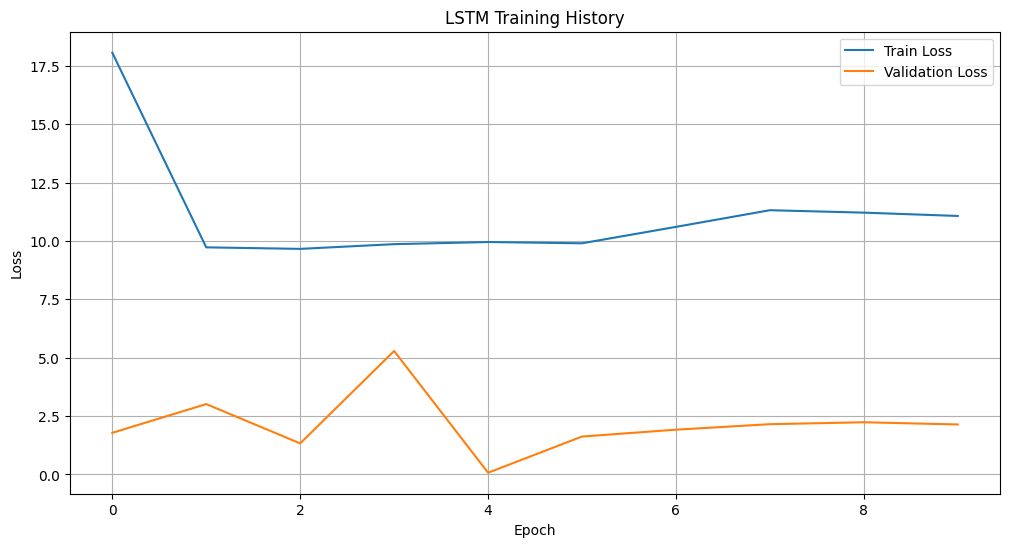

In [152]:
# LOSS CURVES

plt.figure(figsize=(12,6))
plt.plot(history["train_loss"],label="Train Loss")
plt.plot(history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training History")
plt.legend()
plt.grid(True)
plt.show()

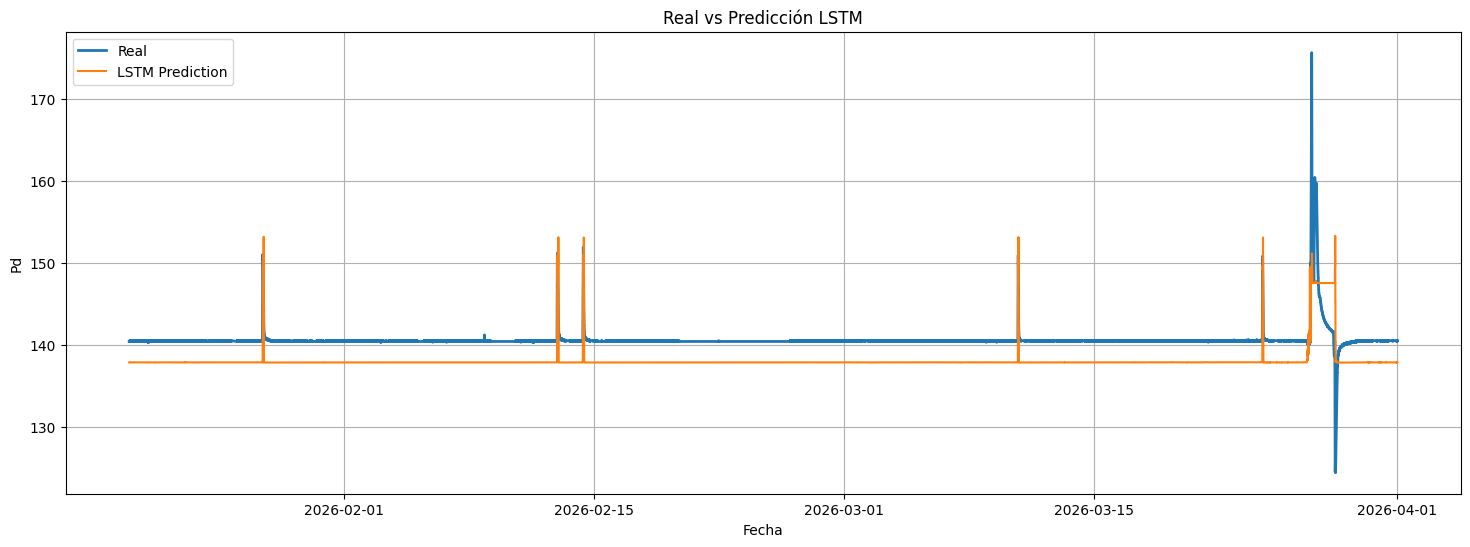

In [153]:
test_index = df_model.index[val_end + SEQ_LEN:]
fecha_inicio = '2026-01-20'
fecha_fin = '2026-04-01'
mask = (test_index >= fecha_inicio) & (test_index <= fecha_fin)

plt.figure(figsize=(18,6))
plt.plot(test_index[mask],y_real_lstm[mask],label="Real",linewidth=2)
plt.plot(test_index[mask],y_pred_lstm[mask],label="LSTM Prediction")

plt.title("Real vs Predicción LSTM")
plt.xlabel("Fecha")
plt.ylabel("Pd")
plt.legend()
plt.grid(True)

plt.show()

In [154]:
error = y_real_lstm - y_pred_lstm

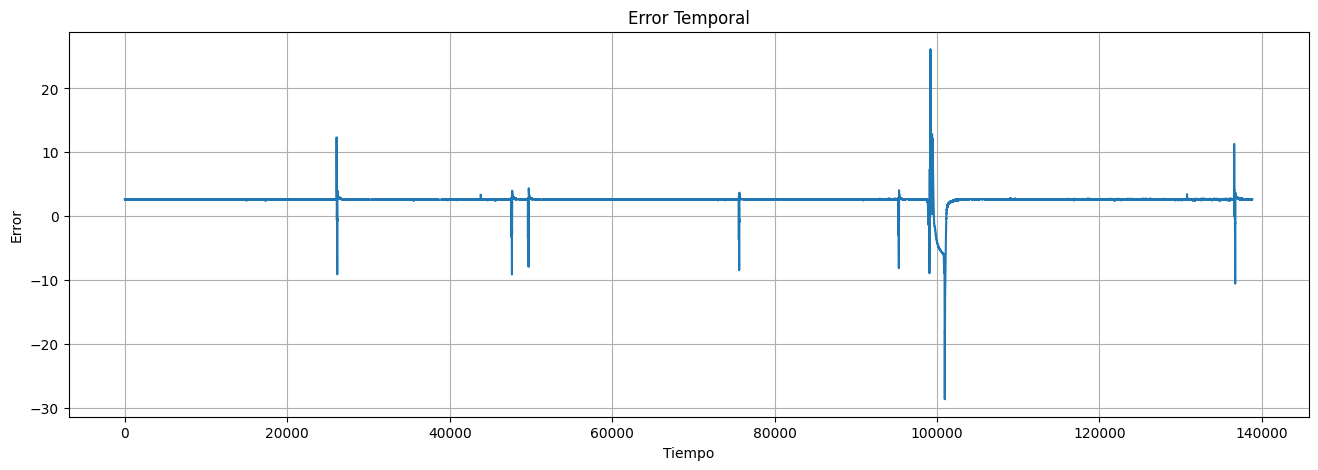

In [155]:
plt.figure(figsize=(16,5))
plt.plot(error)
plt.title("Error Temporal")
plt.xlabel("Tiempo")
plt.ylabel("Error")
plt.grid(True)
plt.show()

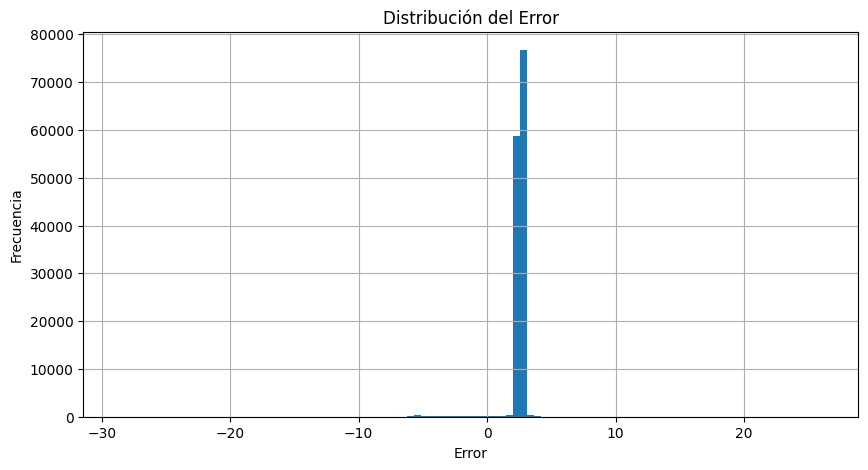

In [156]:
plt.figure(figsize=(10,5))
plt.hist(error,bins=100)
plt.title("Distribución del Error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

### Guardar Modelo

In [157]:
torch.save(model.state_dict(),"lstm_pd_model.pth")
# Guardar scaler
joblib.dump(scaler_X, "scaler_X.pkl")

['scaler_X.pkl']

### Cargar modelo

In [158]:
# primero crear modelo
input_size = len(features)
model = LSTMModel(input_size=input_size,hidden_size=128,num_layers=2,dropout=0.2)
model.load_state_dict(torch.load("lstm_pd_model.pth"))

model.eval()

scaler_X = joblib.load("scaler_X.pkl")

C:\Users\lggom\AppData\Local\Temp\ipykernel_27588\2778239320.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("lstm_pd_model.pth"))
